In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy as sp
import transformers as tfs
import torch as th
import re


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#read and merge the data
fake_df=pd.read_csv('/content/drive/MyDrive/datasets/Fake.csv')
true_df=pd.read_csv('/content/drive/MyDrive/datasets/True.csv')

#Add target label column
fake_df['label']=0
true_df['label']=1

#merge two dataframes into single one
merged_df=pd.concat([fake_df,true_df],ignore_index=True)

print(merged_df.tail(5))
#Save merged df
merged_df.to_csv('/content/drive/MyDrive/datasets/raw_df.csv')

                                                   title  \
44893  'Fully committed' NATO backs new U.S. approach...   
44894  LexisNexis withdrew two products from Chinese ...   
44895  Minsk cultural hub becomes haven from authorities   
44896  Vatican upbeat on possibility of Pope Francis ...   
44897  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text    subject  \
44893  BRUSSELS (Reuters) - NATO allies on Tuesday we...  worldnews   
44894  LONDON (Reuters) - LexisNexis, a provider of l...  worldnews   
44895  MINSK (Reuters) - In the shadow of disused Sov...  worldnews   
44896  MOSCOW (Reuters) - Vatican Secretary of State ...  worldnews   
44897  JAKARTA (Reuters) - Indonesia will buy 11 Sukh...  worldnews   

                   date  label  
44893  August 22, 2017       1  
44894  August 22, 2017       1  
44895  August 22, 2017       1  
44896  August 22, 2017       1  
44897  August 22, 2017       1  


In [ ]:
#Load english model of spacy
# en- english, core- loads core model for vocabulary,syntax, web-Trained on web text like blogs,news, sm- small model
# parser- analyses grammatical structure of sentence like subject and object and how they are related to each other.
#ner- named enitity recogniser, identifies people, places and organisation and we disable them as we dont it and it makes our model lightweight
lp=sp.load("en_core_web_sm",disable=["parser","ner"])

#Preprocessing function
def clean_text(text,lemmatization=True,remove_stopwords=False):
  #Make text Lowercase
  text=text.lower()
  #Remove URLs
  text=re.sub(r"http\S+|www\S+|https\S+",'',text)
  #Remove punctuations, numbers and special characters
  text=re.sub(r"[^a-z\s]",'',text)

  #Lemmetization
  if lemmatization:
    doc=lp(text)
    if remove_stopwords:
      text=" ".join(word.lemma_ for word in doc if not word.is_stop)
    else:
      text=" ".join(word.lemma_ for word in doc)
  return text.strip()

#Combine title and text into one field
merged_df['content']=merged_df['title'].astype(str)+" "+merged_df['text'].astype(str)

#Apply clean text method on new column
merged_df['content']=merged_df['content'].apply(lambda X : clean_text(X,lemmatization=True,remove_stopwords=False))

print(merged_df.head(5))
# Save as CSV
merged_df.to_csv('/content/drive/MyDrive/datasets/cleaned_df.csv', index=False)

/tmp/ipython-input-1946841969.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_df,x='label',palette='viridis')


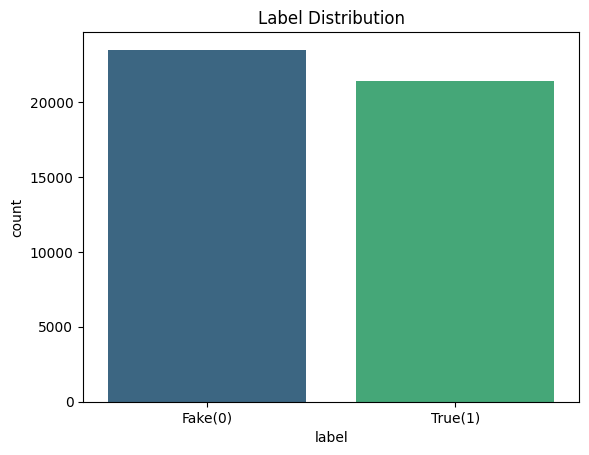

label
0    23481
1    21417
Name: count, dtype: int64


/tmp/ipython-input-1946841969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cleaned_df,x='subject',order=cleaned_df['subject'].value_counts().index,palette='magma')


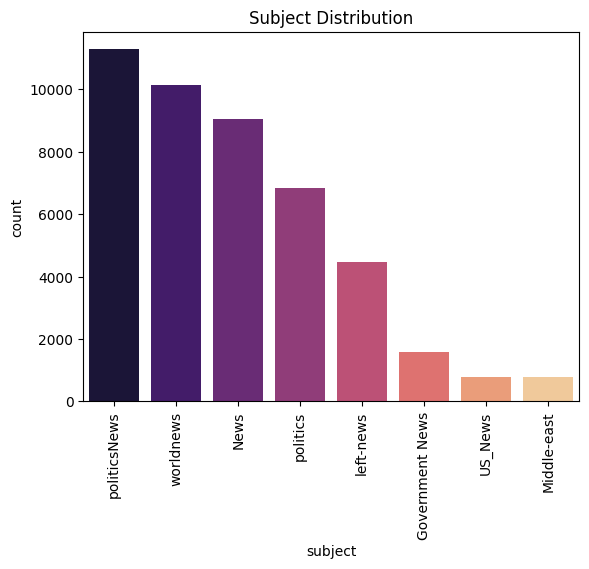

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


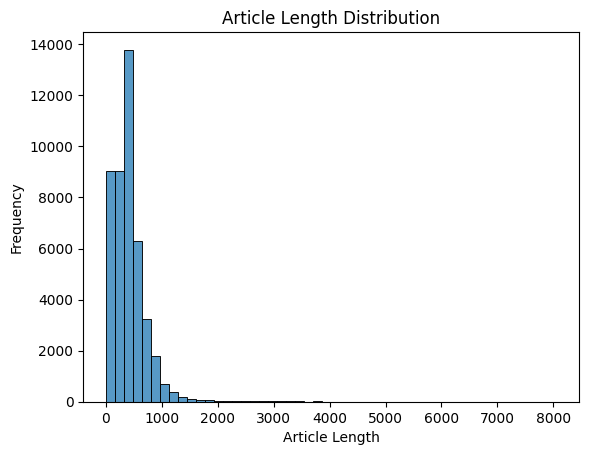

count    44898.000000
mean       412.409484
std        347.425791
min          1.000000
25%        212.000000
50%        370.000000
75%        519.000000
max       8057.000000
Name: article_length, dtype: float64
Top 20 Fake news words =  [('the', 534182), ('be', 339229), ('to', 300201), ('of', 240969), ('and', 228235), ('a', 214215), ('in', 169290), ('that', 151219), ('s', 131615), ('have', 113314), ('for', 96826), ('he', 96602), ('on', 84910), ('trump', 82824), ('it', 79756), ('with', 65382), ('they', 59979), ('his', 59663), ('as', 56902), ('this', 56488)]
Top 20 True news words =  [('the', 482723), ('to', 253011), ('be', 212267), ('of', 207977), ('a', 198493), ('in', 185293), ('and', 182269), ('say', 118176), ('on', 111725), ('have', 110526), ('that', 88363), ('for', 82519), ('he', 62774), ('trump', 58226), ('with', 56001), ('s', 49292), ('as', 48403), ('by', 48229), ('it', 46976), ('not', 43745)]


In [ ]:
#EDA
cleaned_df=pd.read_csv('/content/drive/MyDrive/datasets/cleaned_df.csv')

#Label Distribution
sns.countplot(data=cleaned_df,x='label',palette='viridis')
plt.xticks([0,1],['Fake(0)','True(1)'])
plt.title('Label Distribution')
plt.savefig('/content/drive/MyDrive/Figures/label_distribution.jpg')
plt.show()

print(cleaned_df['label'].value_counts())

#Subject Distribution
sns.countplot(data=cleaned_df,x='subject',order=cleaned_df['subject'].value_counts().index,palette='magma')
plt.xticks(rotation=90)
plt.title('Subject Distribution')
plt.savefig('/content/drive/MyDrive/Figures/subject_distribution.jpg')
plt.show()

print(cleaned_df['subject'].value_counts())

#Artcile Length Distribution
cleaned_df['article_length']=cleaned_df['content'].apply(lambda x:len(str(x).split()))
sns.histplot(cleaned_df['article_length'],bins=50,kde=False)
plt.xlabel('Article Length')
plt.ylabel('Frequency')
plt.title('Article Length Distribution')
plt.savefig('/content/drive/MyDrive/Figures/article_length_distribution.jpg')
plt.show()

print(cleaned_df['article_length'].describe())

#Word counter
from collections import Counter

def get_top_n_words(df,label,n):
  text=df[df['label']==label]['content'].fillna("").astype(str)
  words=" ".join(text).split()
  return Counter(words).most_common(n)

print("Top 20 Fake news words = ",get_top_n_words(cleaned_df,0,20))
print("Top 20 True news words = ",get_top_n_words(cleaned_df,1,20))

In [ ]:
cleaned_df=pd.read_csv('/content/drive/MyDrive/datasets/cleaned_df.csv')
#Drop duplicates artciles
cleaned_df = cleaned_df.drop_duplicates(subset=['content'])
#Feature Extraction using TfIdf
from sklearn.feature_extraction.text import TfidfVectorizer
#Extract features from cleaned df
Vectoriser=TfidfVectorizer(max_features=5000,ngram_range=(1,2))
X_tfidf=Vectoriser.fit_transform(cleaned_df['content'].fillna(""))
y=cleaned_df['label']

print("TF-IDF matrix shape",X_tfidf.shape)

TF-IDF matrix shape (39099, 5000)


In [ ]:
#Train test split
from sklearn.metrics import classification_report,accuracy_score,f1_score
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_tfidf,y,test_size=0.2,random_state=42,stratify=y) #stratify keeps label balance in train/test
results={} # dictionary to store results of each model

#Logistic Regression
from sklearn.linear_model import LogisticRegression


log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train,y_train)
y_pred=log_reg.predict(X_test)
results['Logistic regression']={
    'Accuracy_Score':accuracy_score(y_test,y_pred),
    'F1_Score':f1_score(y_test,y_pred)
}


#Naive bayes classifier
from sklearn.naive_bayes import MultinomialNB

nb_classifier=MultinomialNB()
nb_classifier.fit(X_train,y_train)
y_pred=nb_classifier.predict(X_test)

results['Naive Bayes Classifier']={
    'Accuracy_Score':accuracy_score(y_test,y_pred),
    'F1_Score':f1_score(y_test,y_pred)
}

#SVM
from sklearn.svm import LinearSVC

svm_classifier=LinearSVC(max_iter=2000)
svm_classifier.fit(X_train,y_train)
y_pred=svm_classifier.predict(X_test)
results['SVM Classifier']={
    'Accuracy_Score':accuracy_score(y_test,y_pred),
    'F1_Score':f1_score(y_test,y_pred)
}

#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_classifier=RandomForestClassifier(n_estimators=200)
rf_classifier.fit(X_train,y_train)
y_pred=rf_classifier.predict(X_test)
results['Random Forest Classifier']={
    'Accuracy_Score':accuracy_score(y_test,y_pred),
    'F1_Score':f1_score(y_test,y_pred)
}

#Results
pd.DataFrame(results).T.sort_values(by='F1_Score',ascending=False)

,Accuracy_Score,F1_Score
SVM Classifier,0.995269,0.995638
Random Forest Classifier,0.994885,0.995296
Logistic regression,0.987852,0.988820
Naive Bayes Classifier,0.946803,0.951151


In [ ]:
#cleaned_df=pd.read_csv('/content/drive/MyDrive/datasets/cleaned_df.csv')
#Drop duplicates artciles
#cleaned_df = cleaned_df.drop_duplicates(subset=['content'])
#Transfomers
#Import necessary libraries
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
import torch

#Train test split
train_texts, test_texts, train_labels, test_labels = train_test_split(cleaned_df['content'].fillna("").astype(str).tolist(), cleaned_df['label'].tolist(), test_size=0.2, random_state=42,stratify=cleaned_df['label'])

#Tokenise text into sub-words pieces so BERT can understand
tokeniser = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

#Tokenise train and test texts
def batch_tokenize(texts, batch_size=2000):
    encodings = {'input_ids': [], 'attention_mask': []}
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        e = tokeniser(batch, truncation=True, padding=True, max_length=256)#padding to make all inputs same size
        encodings['input_ids'] += e['input_ids']
        encodings['attention_mask'] += e['attention_mask']
    return encodings

train_encodings = batch_tokenize(train_texts)
test_encodings  = batch_tokenize(test_texts)


#Convert to Torch Datasets
class NewsDatasets(torch.utils.data.Dataset):
  def __init__(self,encodings,labels):
    self.encodings=encodings
    self.labels=labels
  def __getitem__(self,idx):
    item={key:torch.tensor(val[idx]) for key,val in self.encodings.items()}
    item['labels']=torch.tensor(self.labels[idx])
    return item
  def __len__(self):
    return len(self.labels)

train_dataset=NewsDatasets(train_encodings,train_labels)
test_dataset=NewsDatasets(test_encodings,test_labels)

#Load pre trained distilbert model
model=DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels=2)

#Define compute_metrics to evaluate accuracy,precision,recall and f1 score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)#maximum value at each row
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


#Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",
    logging_dir='./logs',
    logging_steps=100,
)

#Trainer
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokeniser,
    compute_metrics=compute_metrics
)

trainer.train()
#Evaluate trainer
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-544117114.py:75: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer=Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.007400,0.005315,0.999105,0.999174,1.000000,0.998349
2,0.003000,0.003972,0.999488,0.999528,1.000000,0.999056
3,0.000000,0.005059,0.999488,0.999528,1.000000,0.999056


{'eval_loss': 0.005058536306023598,
 'eval_accuracy': 0.9994884910485934,
 'eval_f1': 0.9995279679018173,
 'eval_precision': 1.0,
 'eval_recall': 0.9990563812219864,
 'eval_runtime': 52.3547,
 'eval_samples_per_second': 149.366,
 'eval_steps_per_second': 9.34,
 'epoch': 3.0}

In [ ]:
save_path = "/content/drive/MyDrive/models/distilbert_fake_news"

#Save model and tokeniser for future use
model.save_pretrained(save_path)
tokeniser.save_pretrained(save_path)

#Verify if files saved correctly
import os
print("Files saved to:", save_path)
print(os.listdir(save_path))


Files saved to: /content/drive/MyDrive/models/distilbert_fake_news
['model.safetensors', 'config.json', 'special_tokens_map.json', 'tokenizer_config.json', 'tokenizer.json', 'vocab.txt']


In [ ]:
#read and merge the data
covid_fake_df=pd.read_csv('/content/drive/MyDrive/NewsFakeCOVID-19.csv')
covid_true_df=pd.read_csv('/content/drive/MyDrive/NewsRealCOVID-19.csv')

#Add target label column
covid_fake_df['label']=0
covid_true_df['label']=1

#merge two dataframes into single one
covid_merged_df=pd.concat([covid_fake_df,covid_true_df],ignore_index=True)

print(covid_merged_df.tail(5))
#Save merged df
covid_merged_df.to_csv('/content/drive/MyDrive/datasets/covid_df.csv')

     Unnamed: 0     type                                     fact_check_url  \
944       10072  article  https://www.politifact.com/factchecks/2020/aug...   
945       10073  article  https://www.politifact.com/factchecks/2020/aug...   
946       10074     post  https://www.politifact.com/factchecks/2020/aug...   
947       10075  article  https://www.politifact.com/factchecks/2020/aug...   
948       10076  article  https://www.politifact.com/factchecks/2020/aug...   

    archieve                                           news_url news_url2  \
944      NaN                https://www.nabjnahjconvention.com/       NaN   
945      NaN  https://www.newspressnow.com/news/national_new...       NaN   
946      NaN  https://twitter.com/RepCarolMiller/status/1288...       NaN   
947      NaN  https://thefloridachannel.org/videos/8-10-20-g...       NaN   
948      NaN  https://video.aptv.org/video/august-7-2020-gjn...       NaN   

    news_url3 news_url4 news_url5  \
944       NaN       NaN  

In [ ]:
#Load english model of spacy
# en- english, core- loads core model for vocabulary,syntax, web-Trained on web text like blogs,news, sm- small model
# parser- analyses grammatical structure of sentence like subject and object and how they are related to each other.
#ner- named enitity recogniser, identifies people, places and organisation and we disable them as we dont it and it makes our model lightweight
lp=sp.load("en_core_web_sm",disable=["parser","ner"])

#Preprocessing function
def clean_text(text,lemmatization=True,remove_stopwords=False):
  #Make text Lowercase
  text=text.lower()
  #Remove URLs
  text=re.sub(r"http\S+|www\S+|https\S+",'',text)
  #Remove punctuations, numbers and special characters
  text=re.sub(r"[^a-z\s]",'',text)

  #Lemmetization
  if lemmatization:
    doc=lp(text)
    if remove_stopwords:
      text=" ".join(word.lemma_ for word in doc if not word.is_stop)
    else:
      text=" ".join(word.lemma_ for word in doc)
  return text.strip()

#Combine title and text into one field
covid_merged_df['content']=covid_merged_df['title'].astype(str)+" "+covid_merged_df['content'].astype(str)

#Apply clean text method on new column
covid_merged_df['content']=covid_merged_df['content'].apply(lambda X : clean_text(X,lemmatization=True,remove_stopwords=False))

print(covid_merged_df.head(5))
# Save as CSV
covid_merged_df[covid_merged_df['type']=='article'].to_csv('/content/drive/MyDrive/datasets/cleaned_covid_df.csv', index=False)

   Unnamed: 0     type                                     fact_check_url  \
0         889     post  https://healthfeedback.org/claimreview/false-c...   
1         890     post  https://factcheck.afp.com/trump-retweets-false...   
2         891      NaN  https://www.factcheck.org/2020/09/cdc-did-not-...   
3         892     post  https://healthfeedback.org/claimreview/masks-o...   
4         893  article  https://healthfeedback.org/claimreview/human-d...   

                                            archieve  \
0                           https://archive.is/geT2g   
1                            http://archive.is/pZ2Pk   
2  https://projects.propublica.org/politwoops/twe...   
3                           https://archive.vn/k8PJk   
4                           https://archive.is/Af8Xi   

                                            news_url news_url2 news_url3  \
0  https://www.facebook.com/drelizabethdc/posts/1...       NaN       NaN   
1  https://twitter.com/littllemel/status/1299791

In [ ]:
#Cross-generalisation test
covid_cleaned_df=pd.read_csv('/content/drive/MyDrive/datasets/cleaned_covid_df.csv')


#Transfomers
#Import necessary libraries
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
import torch

test_df=covid_cleaned_df

#Load the saved model and tokeniser from Drive
model_path="/content/drive/MyDrive/models/distilbert_fake_news"
model=DistilBertForSequenceClassification.from_pretrained(model_path)
tokeniser=DistilBertTokenizerFast.from_pretrained(model_path)

#Tokenise train and test dfs in batches
def batch_tokenize(texts, batch_size=2000):
    encodings = {'input_ids': [], 'attention_mask': []}
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        e = tokeniser(batch, truncation=True, padding=True, max_length=256)#padding to make all inputs same size
        encodings['input_ids'] += e['input_ids']
        encodings['attention_mask'] += e['attention_mask']
    return encodings

test_df['content'] = test_df['content'].fillna("").astype(str)

test_encodings  = batch_tokenize(test_df['content'].tolist())


#Convert to Torch Datasets
class NewsDatasets(torch.utils.data.Dataset):
  def __init__(self,encodings,labels):
    self.encodings=encodings
    self.labels=labels
  def __getitem__(self,idx):
    item={key:torch.tensor(val[idx]) for key,val in self.encodings.items()}
    item['labels']=torch.tensor(self.labels[idx])
    return item
  def __len__(self):
    return len(self.labels)

test_dataset=NewsDatasets(test_encodings,test_df['label'].tolist())


#Define compute_metrics to evaluate accuracy,precision,recall and f1 score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)#maximum value at each row
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}


#Training Arguments
training_args = TrainingArguments(
    output_dir='./results_cross_topics',
    per_device_eval_batch_size=16,
    report_to="none",    # disable wandb
    logging_dir='./logs',
    logging_steps=100
)


#Trainer
trainer=Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    tokenizer=tokeniser,
    compute_metrics=compute_metrics
)

#Evaluate croos-topic generalisation
results=trainer.evaluate()
print("\n Cross-Topic Evaluation Results:")
for k,v in results.items():
  print(f"{k}: {v}")


/tmp/ipython-input-794704981.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer=Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



 Cross-Topic Evaluation Results:
eval_loss: 5.314938068389893
eval_model_preparation_time: 0.0016
eval_accuracy: 0.2222222222222222
eval_f1: 0.35064935064935066
eval_precision: 0.984375
eval_recall: 0.21331828442437922
eval_runtime: 429.6686
eval_samples_per_second: 2.095
eval_steps_per_second: 0.133


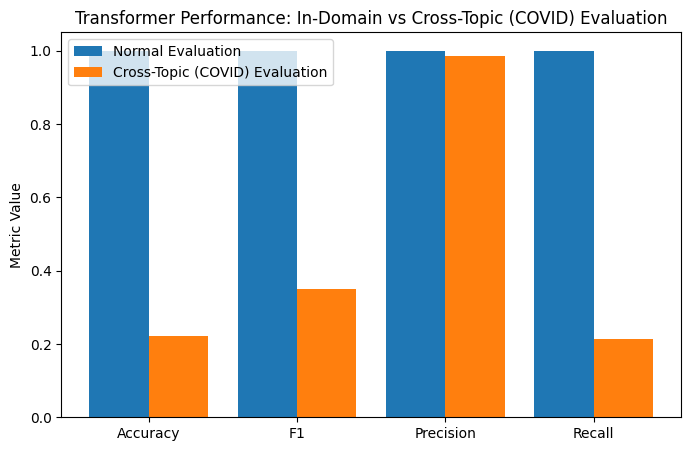

In [ ]:
import matplotlib.pyplot as plt


metrics = ['Accuracy', 'F1', 'Precision', 'Recall']


In_Domain = [0.99949, 0.99953, 1.0, 0.99906]
cross_topic = [0.2222, 0.3506, 0.9844, 0.2133]

x = range(len(metrics))
plt.figure(figsize=(8,5))

plt.bar(x, In_Domain, width=0.4, label='Normal Evaluation', align='center')
plt.bar([i + 0.4 for i in x], cross_domain, width=0.4, label='Cross-Topic (COVID) Evaluation', align='center')

plt.xticks([i + 0.2 for i in x], metrics)
plt.title("Transformer Performance: In-Domain vs Cross-Topic (COVID) Evaluation")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.legend()
plt.show()
